# Activity 2 — COVID-19 Dataset Exploration

**Goal:** Load the provided online CSV, extract Pakistan, handle missing values, plot cases over time, find the day with the highest confirmed cases, and inspect daily-case outliers.

The code uses the URL supplied in the lab.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasets/covid-19/master/data/time-series-19-covid-combined.csv"

covid = pd.read_csv(url)

print(covid.head())
print("\nColumns:")
print(covid.columns.tolist())

         Date Country/Region Province/State  Confirmed  Recovered  Deaths
0  2020-01-22    Afghanistan            NaN          0        0.0       0
1  2020-01-23    Afghanistan            NaN          0        0.0       0
2  2020-01-24    Afghanistan            NaN          0        0.0       0
3  2020-01-25    Afghanistan            NaN          0        0.0       0
4  2020-01-26    Afghanistan            NaN          0        0.0       0

Columns:
['Date', 'Country/Region', 'Province/State', 'Confirmed', 'Recovered', 'Deaths']


## Task 1 — Extract Pakistan

We filter rows where `Country/Region` equals `Pakistan`.

In [2]:
pakistan = covid[covid["Country/Region"] == "Pakistan"].copy()

pakistan.head()

,Date,Country/Region,Province/State,Confirmed,Recovered,Deaths
168912,2020-01-22,Pakistan,NaN,0,0.0,0
168913,2020-01-23,Pakistan,NaN,0,0.0,0
168914,2020-01-24,Pakistan,NaN,0,0.0,0
168915,2020-01-25,Pakistan,NaN,0,0.0,0
168916,2020-01-26,Pakistan,NaN,0,0.0,0


## Task 2 — Handle missing values

First inspect missing values. We only fill numerical columns when needed. For cumulative confirmed cases, forward fill is appropriate because cumulative counts should normally carry the previous known value forward when a value is missing.

For this dataset, you may find that the relevant columns contain no missing values.

In [3]:
print("Missing values:")
print(pakistan.isna().sum())

# Convert date to datetime
pakistan["Date"] = pd.to_datetime(pakistan["Date"])

# Handle missing Confirmed values
pakistan["Confirmed"] = pakistan["Confirmed"].ffill()

print("\nMissing Confirmed values after handling:")
print(pakistan["Confirmed"].isna().sum())

Missing values:
Date                0
Country/Region      0
Province/State    816
Confirmed           0
Recovered           0
Deaths              0
dtype: int64

Missing Confirmed values after handling:
0


## Task 3 — Plot confirmed cases over time

`Date` is placed on the x-axis and cumulative `Confirmed` cases on the y-axis.

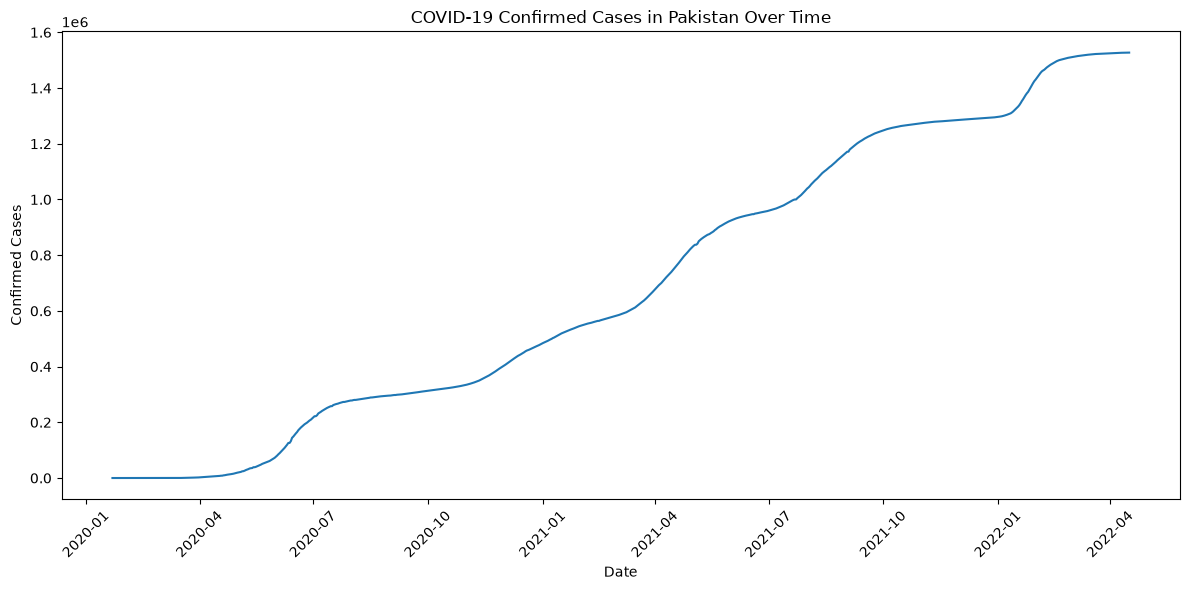

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(pakistan["Date"], pakistan["Confirmed"])
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.title("COVID-19 Confirmed Cases in Pakistan Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Task 4 — Find the day with the highest confirmed cases

Because `Confirmed` is cumulative, this finds the date on which the cumulative confirmed-case count reached its maximum.

In [5]:
max_index = pakistan["Confirmed"].idxmax()
max_row = pakistan.loc[max_index]

print("Day with highest confirmed cases:", max_row["Date"].date())
print("Highest confirmed cases:", int(max_row["Confirmed"]))

Day with highest confirmed cases: 2022-04-16
Highest confirmed cases: 1527248


## Task 5 — Detect outliers in daily cases

The supplied file contains cumulative confirmed cases. To analyze **daily new cases**, calculate the day-to-day difference using `diff()`.

Then use a boxplot and the IQR rule to identify potential outliers.

C:\Users\PMLS\AppData\Local\Temp\ipykernel_21848\392011914.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(pakistan["Daily_Cases"], vert=True)


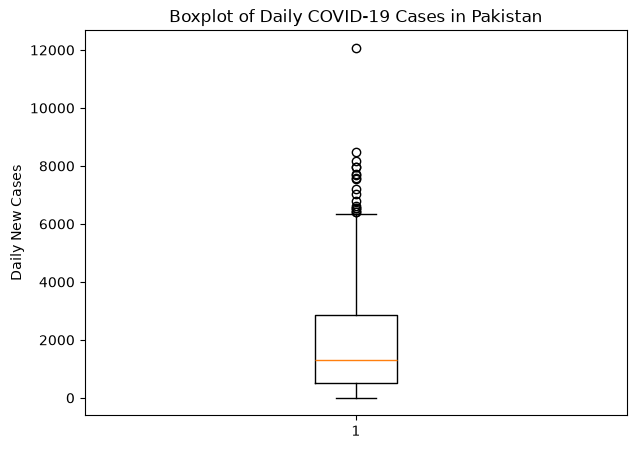

Lower boundary: -3002.125
Upper boundary: 6360.875

Potential daily-case outliers:
             Date  Daily_Cases
169053 2020-06-11       6397.0
169055 2020-06-13       6472.0
169056 2020-06-14      12073.0
169061 2020-06-19       6604.0
169077 2020-07-05       6535.0
169382 2021-05-06       8495.0
169503 2021-09-04       7727.0
169640 2022-01-19       6808.0
169641 2022-01-20       7678.0
169642 2022-01-21       6540.0
169643 2022-01-22       7586.0
169644 2022-01-23       7195.0
169647 2022-01-26       7539.0
169648 2022-01-27       8183.0
169649 2022-01-28       7963.0
169650 2022-01-29       7958.0
169651 2022-01-30       7048.0
169655 2022-02-03       6400.0


In [6]:
pakistan["Daily_Cases"] = pakistan["Confirmed"].diff()

# The first day has no previous day, so its difference is NaN.
pakistan["Daily_Cases"] = pakistan["Daily_Cases"].fillna(0)

plt.figure(figsize=(7, 5))
plt.boxplot(pakistan["Daily_Cases"], vert=True)
plt.ylabel("Daily New Cases")
plt.title("Boxplot of Daily COVID-19 Cases in Pakistan")
plt.show()

Q1 = pakistan["Daily_Cases"].quantile(0.25)
Q3 = pakistan["Daily_Cases"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

daily_outliers = pakistan[
    (pakistan["Daily_Cases"] < lower) |
    (pakistan["Daily_Cases"] > upper)
]

print("Lower boundary:", lower)
print("Upper boundary:", upper)
print("\nPotential daily-case outliers:")
print(daily_outliers[["Date", "Daily_Cases"]])